In [62]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer heatmaps


def plot_matrices(U, V):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.heatmap(U, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title("Latent Matrix A")

    sns.heatmap(V, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title("Latent Matrix B")

    plt.tight_layout()
    plt.show()

In [41]:
# This is new simulation setting for the feature selection:
I = 800
J = 1600
d = d1 = d2 = 100
K = K1 = K2 = 25

U = np.random.normal(0, np.sqrt(0.05), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.05), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.55).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

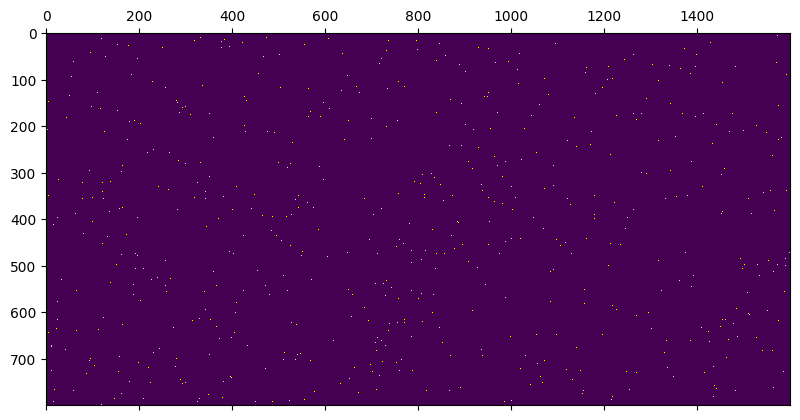

In [43]:
plt.matshow(Y)

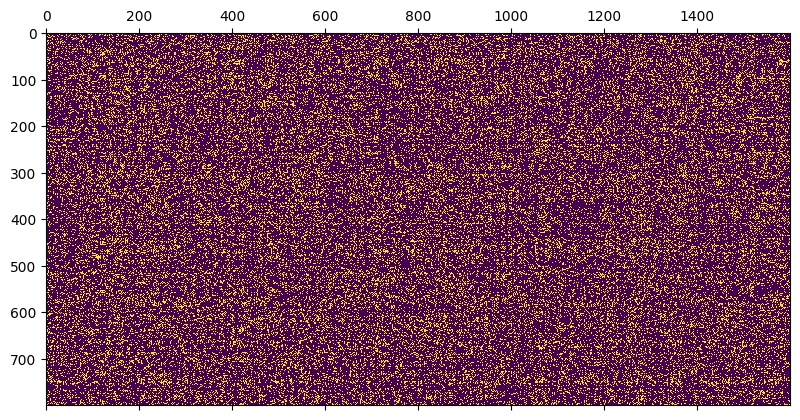

In [42]:
plt.matshow(Y_true)

In [25]:
# This is new simulation setting for the feature selection:
I = 800
J = 1600
d = d1 = d2 = 100
K = K1 = K2 = 25

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.ones((K, K))
B_true = np.ones((K, K))

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

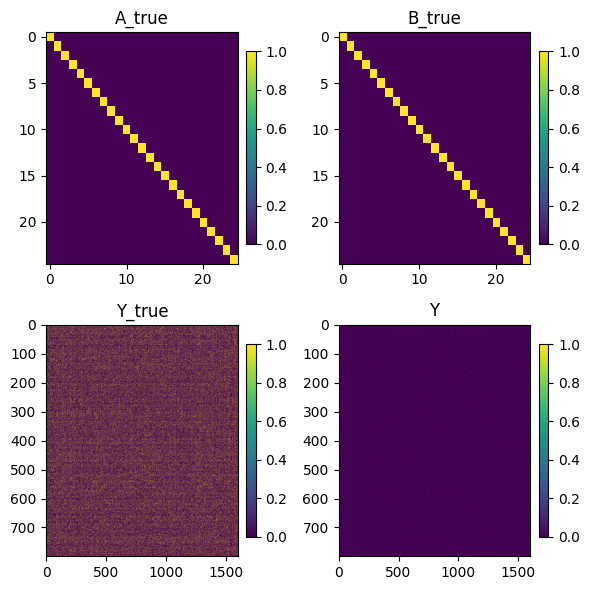

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(A_true, aspect="auto", cmap="viridis")
axes[0, 0].set_title("A_true")
plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(B_true, aspect="auto", cmap="viridis")
axes[0, 1].set_title("B_true")
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(Y_true, aspect="auto", cmap="viridis")
axes[1, 0].set_title("Y_true")
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(Y, aspect="auto", cmap="viridis")
axes[1, 1].set_title("Y")
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [45]:
np.sum(Y)

np.int64(2684)

In [9]:
# U.shape, V.shape, A_true.shape
A = np.zeros((d1, K))
A[range(K)] = A_true
A[K:] = np.random.normal(size=A[K:].shape) / 10
Ainput = A.copy()

B = np.zeros((d2, K))
B[range(K)] = B_true
B[K:] = np.random.normal(size=B[K:].shape) / 10
Binput = B.copy()

In [ ]:
plt.matshow(Ainput)
# print(Ainput)

In [ ]:
est_mu, est_A, est_B, logLik = BiSSGL.optimization(
    Y,
    U=U,
    V=V,
    xi=5,
    eta=0.000001,
    tilde_lambda0=5,
    tilde_lambda1=1,
    tilde_alpha=1 / K,
    tilde_beta=1,
    lambda0=5,
    lambda1=1,
    alpha=1 / K,
    beta=1,
    K=K,
    max_iter=10000,
    tol=1e-5,
    # A=Ainput,
    # B=Binput,
)

[ 685.9538699   286.59507883  224.77387554   90.98295334  254.57024979
  -54.0374895   213.52865747 -829.89985303 -147.54648033  221.39106144
 -621.49160691 -686.04718662 -308.0015722  -447.77571983 -826.74438291
  -89.89516399  409.67710205  -92.6275895   275.24044204 -460.80021102
  220.9579689    96.38758683 -121.91736448  -27.72038842  396.78549392]
[ -428.59370228    36.0065959  -1102.4337664   -688.83960186
  1034.486917     237.5340816    783.42023235  -946.67336476
  -980.99593924   941.44882812  -228.47422096   424.73776934
   871.27716119   -54.95750316  -215.31694918 -1653.48685588
   231.15180043  -217.84581664   444.41199088   -14.50633378
  -435.18343646   975.94741296  -587.79926188 -1498.91106073
   130.83947874]
[ 683.27157014  284.01045829  224.77224169   88.61310053  254.73251782
  -53.68033357  212.90686476 -828.96311133 -148.22453109  220.08648827
 -620.18092625 -683.63739742 -306.8408481  -444.73576992 -824.13222916
  -88.5495156   409.66552808  -90.92699566  274.

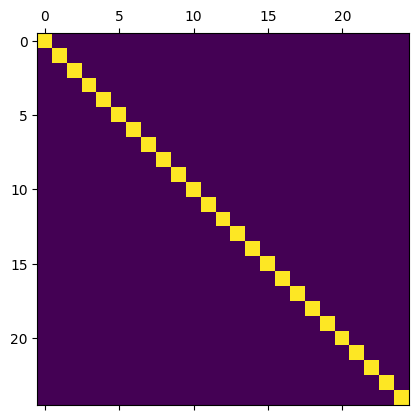

In [75]:
plt.matshow(A_true)

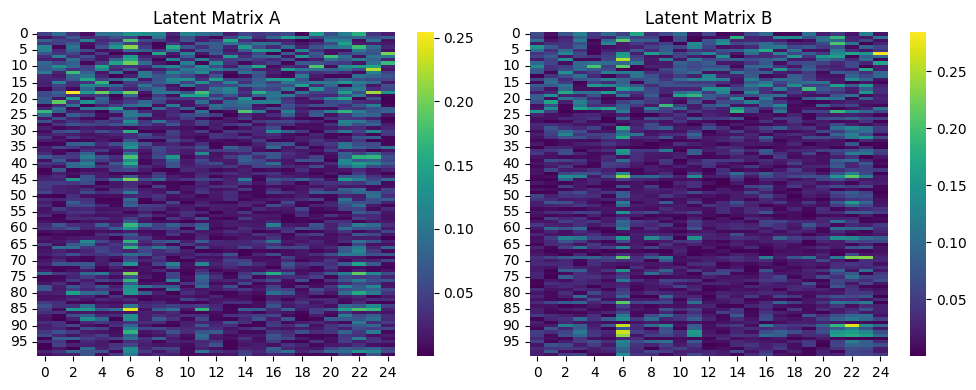

In [76]:
plot_matrices(np.abs(est_A), np.abs(est_B))

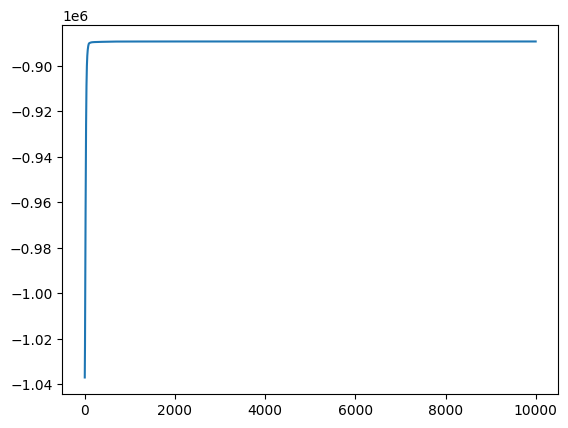

In [77]:
plt.plot(range(len(logLik)), logLik)

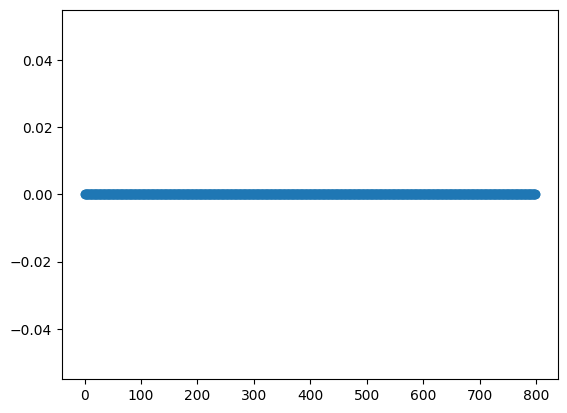

In [65]:
plt.plot(est_mu, marker="o")

In [78]:
print(est_A)

[[-0.04807751 -0.08907059 -0.03772435 ...  0.16173705  0.03605354
   0.02007545]
 [-0.01119758 -0.03188483 -0.07045315 ...  0.08111044 -0.06238413
  -0.07651026]
 [-0.07848748  0.05320133  0.04442388 ...  0.00898101 -0.09812348
  -0.01228482]
 ...
 [-0.00151806  0.01423195 -0.00079289 ... -0.0651621   0.07792513
  -0.0479805 ]
 [-0.02424431  0.03763678  0.08682845 ... -0.13219087  0.11712113
  -0.0598012 ]
 [ 0.00926526  0.02127489  0.02147944 ... -0.00590192  0.06480948
   0.00561866]]


<StemContainer object of 3 artists>

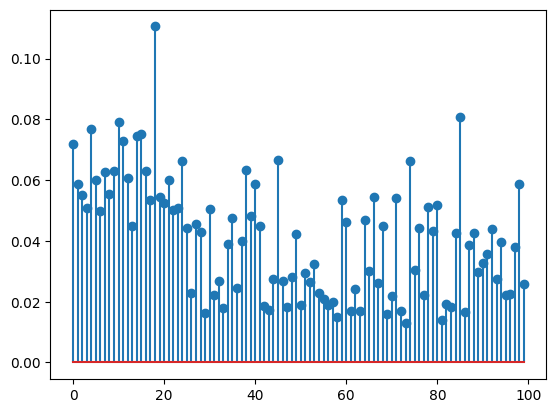

In [ ]:
plt.stem(np.abs(est_A).mean(axis=1))

<StemContainer object of 3 artists>

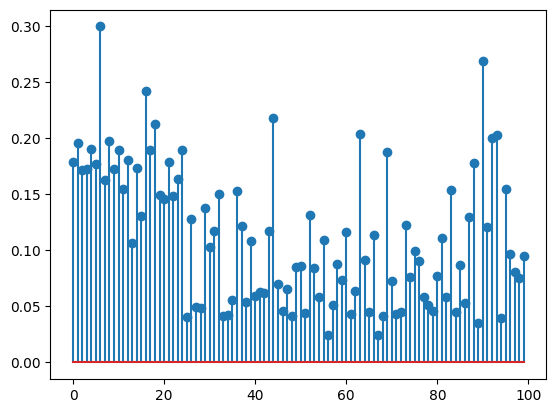

In [73]:
plt.stem(np.abs(est_B).max(axis=1))

In [84]:
est_pr = expit(U @ est_A @ est_B.T @ V.T)
est_pr_masked = est_pr[masked_indices[:, 0], masked_indices[:, 1]]
y_test = Y_masked
y_score = est_pr_masked

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.metrics import auc


# Data to plot precision - recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.2731472068399645


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_tpr_fpr = auc(tpr, 1 - fpr)
print(auc_tpr_fpr)

print(roc_auc_score(y_test, y_score))

0.6135564427222711
0.6135564427222711


In [89]:
help(roc_curve)

Help on function roc_curve in module sklearn.metrics._ranking:

roc_curve(
    y_true,
    y_score,
    *,
    pos_label=None,
    sample_weight=None,
    drop_intermediate=True
)
    Compute Receiver operating characteristic (ROC).

    Note: this implementation is restricted to the binary classification task.

    Read more in the :ref:`User Guide <roc_metrics>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True binary labels. If labels are not either {-1, 1} or {0, 1}, then
        pos_label should be explicitly given.

    y_score : array-like of shape (n_samples,)
        Target scores, can either be probability estimates of the positive
        class, confidence values, or non-thresholded measure of decisions
        (as returned by "decision_function" on some classifiers).
        For :term:`decision_function` scores, values greater than or equal to
        zero should indicate the positive class.

    pos_label : int, float, bool or str, 